# TimePFN LMC-Synth: oracle-latent and end-to-end VAR coverage

This experiment is exclusively about TimePFN's LMC-Synth construction. Eleven fixed LMC mechanisms
use all 33 entries of the inherited KernelSynth bank exactly once as latent functions (three latents
per mechanism), with a retained four-channel Dirichlet mixing matrix. Every generated LMC mechanism
is evaluated in both oracle-latent AR and end-to-end VAR modes.

Each mechanism generates 16 independent training trajectories and 16 new test trajectories of length
1,024. “All functions” means every latent and every LMC mechanism generated in this finite notebook;
it does not claim to enumerate every possible LMC draw.

Official provenance: `egetaga/TimePFN`, commit
`e11d5c2982b0e49b87873cbddcb7712641861268`,
`synthetic_data_generation/LMC_Synth.py`.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.signal import periodogram
from scipy.stats import wasserstein_distance
from sklearn.gaussian_process.kernels import (
    ConstantKernel, DotProduct, ExpSineSquared, RBF, RationalQuadratic, WhiteKernel
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
MAX_ACF_LAG = 64
THRESHOLDS = {
    "acf_mae": 0.10,
    "psd_jsd": 0.10,
    "abs_log_variance_ratio": 0.25,
    "standardized_wasserstein": 0.25,
}
time = np.linspace(0.0, 1.0, LENGTH)[:, None]

ORDERS = [1, 2, 4, 8, 16, 32, 64, 128]
PERIODS = [
    24, 48, 96, 24 * 7, 48 * 7, 96 * 7, 7, 14, 30, 60, 365, 365 * 2,
    4, 26, 52, 4, 6, 12, 4, 4 * 10, 10,
]
KERNEL_BANK = []
for index, period in enumerate(PERIODS, start=1):
    KERNEL_BANK.append({
        "id": f"periodic_{index:02d}_p{period}",
        "formula": f"ExpSineSquared(length_scale=1, periodicity={period}/1024)",
        "family": "periodic",
        "kernel": ExpSineSquared(length_scale=1.0, periodicity=period / LENGTH),
    })
for sigma in [0.0, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"linear_sigma{sigma:g}", "formula": f"DotProduct(sigma_0={sigma:g})",
                        "family": "linear", "kernel": DotProduct(sigma_0=sigma)})
for scale in [0.1, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"rbf_scale{scale:g}", "formula": f"RBF(length_scale={scale:g})",
                        "family": "rbf", "kernel": RBF(length_scale=scale)})
for alpha in [0.1, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"rq_alpha{alpha:g}",
                        "formula": f"RationalQuadratic(length_scale=1, alpha={alpha:g})",
                        "family": "rational_quadratic",
                        "kernel": RationalQuadratic(length_scale=1.0, alpha=alpha)})
for level in [0.1, 1.0]:
    KERNEL_BANK.append({"id": f"white_level{level:g}", "formula": f"WhiteKernel(noise_level={level:g})",
                        "family": "white", "kernel": WhiteKernel(noise_level=level)})
KERNEL_BANK.append({"id": "constant_1", "formula": "ConstantKernel(constant_value=1)",
                    "family": "constant", "kernel": ConstantKernel(constant_value=1.0)})
assert len(KERNEL_BANK) == 33

def covariance(kernel):
    matrix = np.asarray(kernel(time), dtype=float)
    return (matrix + matrix.T) / 2


def stable_factor(matrix):
    scale = max(float(np.mean(np.diag(matrix))), 1.0)
    identity = np.eye(len(matrix))
    for exponent in range(-10, -3):
        try:
            return np.linalg.cholesky(matrix + (10.0**exponent) * scale * identity)
        except np.linalg.LinAlgError:
            pass
    values, vectors = np.linalg.eigh((matrix + matrix.T) / 2)
    return vectors @ np.diag(np.sqrt(np.maximum(values, 1e-8 * scale)))


def draw_from_factor(factor, count, local_rng):
    return local_rng.standard_normal((count, factor.shape[0])) @ factor.T


def standardize_train_test(train, test):
    mean = float(np.mean(train))
    scale = float(np.std(train) + 1e-12)
    return (train - mean) / scale, (test - mean) / scale, mean, scale


def lagged_design(series, order):
    xs, ys = [], []
    for trajectory in series:
        windows = np.lib.stride_tricks.sliding_window_view(trajectory, order + 1)
        xs.append(windows[:, :-1][:, ::-1])
        ys.append(windows[:, -1])
    return np.vstack(xs), np.concatenate(ys)


@dataclass
class ARFit:
    intercept: float
    coefficients: np.ndarray
    innovation_variance: float


def fit_ar(series, order):
    x, y = lagged_design(series, order)
    design = np.column_stack([np.ones(len(x)), x])
    penalty = RIDGE * np.eye(design.shape[1]); penalty[0, 0] = 0.0
    beta = np.linalg.solve(design.T @ design + penalty, design.T @ y)
    residual = y - design @ beta
    return ARFit(float(beta[0]), beta[1:], float(np.mean(residual**2) + 1e-10))


def ar_predictions(fit, series):
    x, _ = lagged_design(series, len(fit.coefficients))
    return fit.intercept + x @ fit.coefficients


def simulate_ar(fit, initials, length, local_rng):
    order = len(fit.coefficients)
    output = np.zeros((len(initials), length)); output[:, :order] = initials[:, :order]
    noise = local_rng.normal(scale=np.sqrt(fit.innovation_variance), size=output.shape)
    for t in range(order, length):
        output[:, t] = fit.intercept + output[:, t-order:t][:, ::-1] @ fit.coefficients + noise[:, t]
        output[:, t] = np.clip(output[:, t], -1e8, 1e8)
    return output


def acf_vector(values, max_lag):
    centered = values - values.mean(axis=1, keepdims=True)
    denom = np.mean(centered**2, axis=1) + 1e-12
    return np.array([np.mean(np.mean(centered[:, :-lag] * centered[:, lag:], axis=1) / denom)
                     for lag in range(1, max_lag + 1)])


def psd_distribution(values):
    _, power = periodogram(values, axis=1, detrend=False)
    power = np.mean(power, axis=0) + 1e-12
    return power / power.sum()


def js_divergence(p, q):
    middle = 0.5 * (p + q)
    return float(0.5 * np.sum(p * np.log(p / middle)) + 0.5 * np.sum(q * np.log(q / middle)))


def distribution_metrics(reference, generated, start):
    ref, gen = reference[:, start:], generated[:, start:]
    ref_scale = float(np.std(ref) + 1e-12)
    return {
        "acf_mae": float(np.mean(np.abs(acf_vector(ref, MAX_ACF_LAG) - acf_vector(gen, MAX_ACF_LAG)))),
        "psd_jsd": js_divergence(psd_distribution(ref), psd_distribution(gen)),
        "abs_log_variance_ratio": float(abs(np.log((np.var(gen) + 1e-12) / (np.var(ref) + 1e-12)))),
        "standardized_wasserstein": float(wasserstein_distance(ref.ravel(), gen.ravel()) / ref_scale),
    }


def passes(metrics):
    return all(np.isfinite(metrics[key]) and metrics[key] <= value for key, value in THRESHOLDS.items())


def violation_score(row, include_cross=False):
    score = sum(max(float(row[key]) / value - 1.0, 0.0) for key, value in THRESHOLDS.items())
    if include_cross:
        score += max(float(row["cross_corr_frobenius"]) / 0.10 - 1.0, 0.0)
    return score

@dataclass
class VARFit:
    intercept: np.ndarray
    coefficients: np.ndarray
    innovation_covariance: np.ndarray
    order: int
    channels: int


def var_design(series, order):
    xs, ys = [], []
    for trajectory in series:
        windows = np.lib.stride_tricks.sliding_window_view(trajectory, order + 1, axis=0)
        # windows: time, channel, lag; reverse lag history and flatten lag-major.
        xs.append(windows[:, :, :-1][:, :, ::-1].transpose(0, 2, 1).reshape(len(windows), -1))
        ys.append(windows[:, :, -1])
    return np.vstack(xs), np.vstack(ys)


def fit_var(series, order):
    x, y = var_design(series, order)
    design = np.column_stack([np.ones(len(x)), x])
    penalty = RIDGE * np.eye(design.shape[1]); penalty[0, 0] = 0.0
    beta = np.linalg.solve(design.T @ design + penalty, design.T @ y)
    residual = y - design @ beta
    covariance = residual.T @ residual / len(residual) + 1e-8 * np.eye(y.shape[1])
    return VARFit(beta[0], beta[1:], covariance, order, y.shape[1])


def simulate_var(fit, initials, length, local_rng):
    output = np.zeros((len(initials), length, fit.channels)); output[:, :fit.order] = initials[:, :fit.order]
    noise = local_rng.multivariate_normal(np.zeros(fit.channels), fit.innovation_covariance,
                                         size=(len(initials), length))
    for t in range(fit.order, length):
        x = output[:, t-fit.order:t][:, ::-1, :].reshape(len(initials), -1)
        output[:, t] = np.clip(fit.intercept + x @ fit.coefficients + noise[:, t], -1e8, 1e8)
    return output


def channel_metrics(reference, generated, start):
    individual = [distribution_metrics(reference[:, :, channel], generated[:, :, channel], start)
                  for channel in range(reference.shape[2])]
    metrics = {key: float(np.mean([item[key] for item in individual])) for key in THRESHOLDS}
    ref = reference[:, start:].reshape(-1, reference.shape[2])
    gen = generated[:, start:].reshape(-1, generated.shape[2])
    metrics["cross_corr_frobenius"] = float(
        np.linalg.norm(np.corrcoef(ref, rowvar=False) - np.corrcoef(gen, rowvar=False), ord="fro")
        / reference.shape[2])
    return metrics


def lmc_passes(metrics):
    return passes(metrics) and metrics["cross_corr_frobenius"] <= 0.10


## Generate all recorded LMC mechanisms

The official construction samples latent KernelSynth functions and combines them with Dirichlet
weights. Here, grouping consecutive bank entries into eleven triples guarantees that every official
latent function is exercised. The mixing concentration cycles through 0.2, 0.5, 1.0, and 2.0 and is
part of the retained ground truth.

In [2]:
latent_covariances = [covariance(item["kernel"]) for item in KERNEL_BANK]
latent_factors = [stable_factor(matrix) for matrix in latent_covariances]
mechanism_rng = np.random.default_rng(GLOBAL_SEED + 20_000)
LMC_MECHANISMS = []
for number in range(11):
    indices = list(range(3 * number, 3 * number + 3))
    alpha = [0.2, 0.5, 1.0, 2.0][number % 4]
    mixing = mechanism_rng.dirichlet(alpha * np.ones(3), size=4)
    LMC_MECHANISMS.append({"id": f"lmc_{number + 1:02d}", "latent_indices": indices,
                           "latent_ids": [KERNEL_BANK[i]["id"] for i in indices],
                           "latent_formulas": [KERNEL_BANK[i]["formula"] for i in indices],
                           "dirichlet_alpha": alpha, "mixing": mixing})
display(pd.DataFrame([{k: m[k] for k in ["id", "latent_ids", "dirichlet_alpha"]} for m in LMC_MECHANISMS]))

,id,latent_ids,dirichlet_alpha
0,lmc_01,"[periodic_01_p24, periodic_02_p48, periodic_03...",0.2
1,lmc_02,"[periodic_04_p168, periodic_05_p336, periodic_...",0.5
2,lmc_03,"[periodic_07_p7, periodic_08_p14, periodic_09_...",1.0
3,lmc_04,"[periodic_10_p60, periodic_11_p365, periodic_1...",2.0
4,lmc_05,"[periodic_13_p4, periodic_14_p26, periodic_15_...",0.2
5,lmc_06,"[periodic_16_p4, periodic_17_p6, periodic_18_p12]",0.5
6,lmc_07,"[periodic_19_p4, periodic_20_p40, periodic_21_...",1.0
7,lmc_08,"[linear_sigma0, linear_sigma1, linear_sigma10]",2.0
8,lmc_09,"[rbf_scale0.1, rbf_scale1, rbf_scale10]",0.2
9,lmc_10,"[rq_alpha0.1, rq_alpha1, rq_alpha10]",0.5


## Fit every mechanism in both evaluation modes

The oracle-latent method observes each latent during fitting and then applies the true retained
mixing matrix. The end-to-end VAR observes only the four output channels. Coverage requires the four
univariate process thresholds plus cross-channel correlation error ≤ 0.10.

In [3]:
rows = []
for mechanism_index, mechanism in enumerate(LMC_MECHANISMS):
    local_rng = np.random.default_rng(GLOBAL_SEED + 200_000 + mechanism_index)
    raw_train_latents = np.stack([draw_from_factor(latent_factors[i], N_TRAIN, local_rng)
                                  for i in mechanism["latent_indices"]], axis=1)
    raw_test_latents = np.stack([draw_from_factor(latent_factors[i], N_TEST, local_rng)
                                 for i in mechanism["latent_indices"]], axis=1)
    latent_means = raw_train_latents.mean(axis=(0, 2))
    latent_scales = raw_train_latents.std(axis=(0, 2)) + 1e-12
    train_latents = (raw_train_latents - latent_means[None, :, None]) / latent_scales[None, :, None]
    test_latents = (raw_test_latents - latent_means[None, :, None]) / latent_scales[None, :, None]
    raw_train_channels = np.einsum("cq,nqt->ntc", mechanism["mixing"], raw_train_latents)
    raw_test_channels = np.einsum("cq,nqt->ntc", mechanism["mixing"], raw_test_latents)
    channel_means = raw_train_channels.mean(axis=(0, 1)); channel_scales = raw_train_channels.std(axis=(0, 1)) + 1e-12
    train_channels = (raw_train_channels - channel_means) / channel_scales
    test_channels = (raw_test_channels - channel_means) / channel_scales

    for order in ORDERS:
        latent_fits = [fit_ar(train_latents[:, q, :], order) for q in range(3)]
        simulated_standard_latents = np.stack([
            simulate_ar(fit, test_latents[:, q, :order], LENGTH,
                        np.random.default_rng(GLOBAL_SEED + 2_000_000 + 10000 * mechanism_index + 100 * order + q))
            for q, fit in enumerate(latent_fits)], axis=1)
        simulated_raw_latents = (simulated_standard_latents * latent_scales[None, :, None]
                                 + latent_means[None, :, None])
        oracle_raw_channels = np.einsum("cq,nqt->ntc", mechanism["mixing"], simulated_raw_latents)
        oracle_channels = (oracle_raw_channels - channel_means) / channel_scales

        var_fit = fit_var(train_channels, order)
        var_channels = simulate_var(var_fit, test_channels[:, :order], LENGTH,
                                    np.random.default_rng(GLOBAL_SEED + 3_000_000 + 1000 * mechanism_index + order))
        for model, generated in [("oracle_latent_AR", oracle_channels), ("end_to_end_VAR", var_channels)]:
            metrics = channel_metrics(test_channels, generated, order)
            rows.append({"mechanism": mechanism["id"], "latent_ids": ", ".join(mechanism["latent_ids"]),
                         "model": model, "order": order, **metrics, "well_covered": lmc_passes(metrics)})

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(lambda row: violation_score(row, include_cross=True), axis=1)
best = (results.sort_values(["mechanism", "model", "violation_score", "order"])
        .groupby(["mechanism", "model"], as_index=False).first())
status = (results.groupby(["mechanism", "model"])["well_covered"].any()
          .rename("well_covered_any_order").reset_index())
best = best.merge(status, on=["mechanism", "model"], suffixes=("", "_status"))
coverage_curve = results.groupby(["model", "order"])["well_covered"].mean().unstack(0)
display(best[["mechanism", "latent_ids", "model", "order", "well_covered_any_order",
              "acf_mae", "psd_jsd", "abs_log_variance_ratio", "standardized_wasserstein",
              "cross_corr_frobenius"]].round(4))

,mechanism,latent_ids,model,order,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,cross_corr_frobenius
0,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",end_to_end_VAR,32,True,0.0917,0.0886,0.1258,0.2068,0.0521
1,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",oracle_latent_AR,64,True,0.0049,0.0005,0.0019,0.0099,0.0037
2,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",end_to_end_VAR,2,False,0.0675,0.1672,0.1628,0.1131,0.0475
3,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",oracle_latent_AR,2,False,0.0705,0.1496,0.1741,0.1163,0.0334
4,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",end_to_end_VAR,32,True,0.0004,0.0000,0.0004,0.0013,0.0002
5,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",oracle_latent_AR,32,True,0.0001,0.0000,0.0000,0.0005,0.0000
6,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",end_to_end_VAR,4,False,0.0991,0.2456,0.0965,0.0954,0.0180
7,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",oracle_latent_AR,128,False,0.0867,0.0213,0.6361,0.1925,0.0692
8,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",end_to_end_VAR,32,True,0.0621,0.0267,0.0490,0.0718,0.0593
9,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",oracle_latent_AR,32,True,0.0583,0.0237,0.0321,0.0505,0.0141


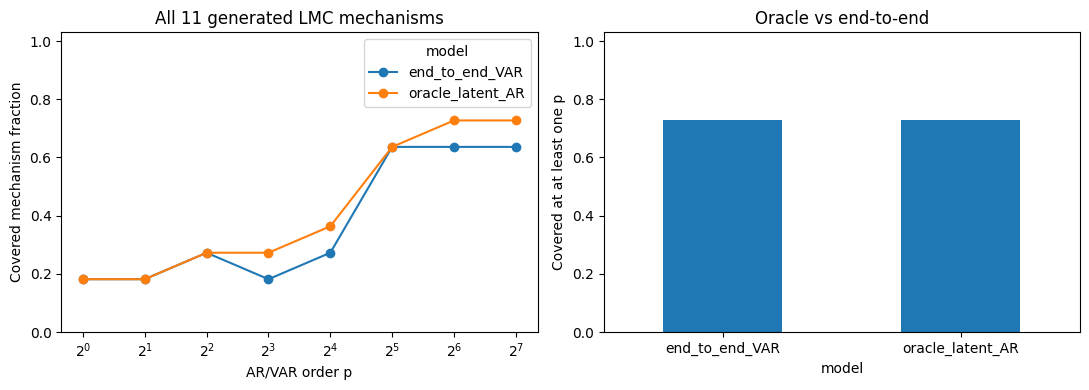

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
coverage_curve.plot(marker="o", ax=axes[0]); axes[0].set_xscale("log", base=2); axes[0].set_ylim(0, 1.03)
axes[0].set_xlabel("AR/VAR order p"); axes[0].set_ylabel("Covered mechanism fraction")
axes[0].set_title("All 11 generated LMC mechanisms")
model_summary = best.groupby("model")["well_covered_any_order"].mean()
model_summary.plot.bar(ax=axes[1], rot=0); axes[1].set_ylim(0, 1.03)
axes[1].set_ylabel("Covered at at least one p"); axes[1].set_title("Oracle vs end-to-end")
fig.tight_layout(); plt.show()

## Final classification of every generated LMC function

In [5]:
covered_pairs = best.loc[best.well_covered_any_order, ["mechanism", "model"]]
not_covered_pairs = best.loc[~best.well_covered_any_order, ["mechanism", "model"]]
covered_functions = [f"{row.mechanism} [{row.model}]" for row in covered_pairs.itertuples()]
not_covered_functions = [f"{row.mechanism} [{row.model}]" for row in not_covered_pairs.itertuples()]
print(f"WELL COVERED ({len(covered_functions)}/{len(best)} mechanism/model pairs):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)} mechanism/model pairs):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["mechanism", "latent_ids", "model", "order", "well_covered_any_order"]])

WELL COVERED (16/22 mechanism/model pairs):
  - lmc_01 [end_to_end_VAR]
  - lmc_01 [oracle_latent_AR]
  - lmc_03 [end_to_end_VAR]
  - lmc_03 [oracle_latent_AR]
  - lmc_05 [end_to_end_VAR]
  - lmc_05 [oracle_latent_AR]
  - lmc_06 [end_to_end_VAR]
  - lmc_06 [oracle_latent_AR]
  - lmc_07 [end_to_end_VAR]
  - lmc_07 [oracle_latent_AR]
  - lmc_08 [end_to_end_VAR]
  - lmc_08 [oracle_latent_AR]
  - lmc_10 [end_to_end_VAR]
  - lmc_10 [oracle_latent_AR]
  - lmc_11 [end_to_end_VAR]
  - lmc_11 [oracle_latent_AR]

NOT WELL COVERED (6/22 mechanism/model pairs):
  - lmc_02 [end_to_end_VAR]
  - lmc_02 [oracle_latent_AR]
  - lmc_04 [end_to_end_VAR]
  - lmc_04 [oracle_latent_AR]
  - lmc_09 [end_to_end_VAR]
  - lmc_09 [oracle_latent_AR]


,mechanism,latent_ids,model,order,well_covered_any_order
0,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",end_to_end_VAR,32,True
1,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",oracle_latent_AR,64,True
2,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",end_to_end_VAR,2,False
3,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",oracle_latent_AR,2,False
4,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",end_to_end_VAR,32,True
5,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",oracle_latent_AR,32,True
6,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",end_to_end_VAR,4,False
7,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",oracle_latent_AR,128,False
8,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",end_to_end_VAR,32,True
9,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",oracle_latent_AR,32,True


In [6]:
def git_output(*args):
    try: return subprocess.check_output(["git", *args], text=True).strip()
    except Exception as exc: return f"unavailable: {exc}"

# COMPLETE EXPERIMENT RECORD — canonical record for this executed notebook.
experiment_record = {
    "experiment_id": "timepfn_lmc_ar_var_coverage_002",
    "status": "completed",
    "research_question": "Which generated TimePFN LMC-Synth mechanisms are well approximated by oracle-latent AR and end-to-end VAR models?",
    "hypothesis": "Oracle latent access should require no greater order than end-to-end VAR, while both improve non-monotonically with p.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST, "orders": ORDERS,
                      "channels": 4, "latents_per_mechanism": 3, "ridge": RIDGE,
                      "max_acf_lag": MAX_ACF_LAG, "thresholds": THRESHOLDS,
                      "cross_corr_threshold": 0.10,
                      "mechanisms": [{"id": m["id"], "latent_ids": m["latent_ids"],
                                      "latent_formulas": m["latent_formulas"],
                                      "dirichlet_alpha": m["dirichlet_alpha"],
                                      "mixing": m["mixing"].tolist()} for m in LMC_MECHANISMS]},
    "provenance": {"repository": "https://github.com/egetaga/TimePFN",
                   "commit": "e11d5c2982b0e49b87873cbddcb7712641861268",
                   "source": "synthetic_data_generation/LMC_Synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED, "policy": "derived per LMC mechanism, model, latent, and order; train/test draws independent"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_model_and_order": coverage_curve.to_dict(),
                "best_row_per_mechanism_and_model": best.to_dict(orient="records")},
    "covered_functions": covered_functions,
    "not_well_covered_functions": not_covered_functions,
    "scientific_summary": (f"{len(covered_functions)}/{len(best)} generated mechanism/model pairs were well covered at at least one order. "
                           "All 33 official latent-bank entries were exercised once across the eleven retained LMC mechanisms."),
    "limitations": ["Eleven retained LMC draws do not exhaust the stochastic LMC prior.",
                    "Operational thresholds need sensitivity analysis.", "No Monte Carlo confidence intervals.",
                    "Linear Gaussian homoskedastic AR/VAR search only."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\AR\02_timepfn_lmc_ar_var_coverage.ipynb --output 02_timepfn_lmc_ar_var_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False, default=lambda value: float(value)))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "timepfn_lmc_ar_var_coverage_002",
  "status": "completed",
  "research_question": "Which generated TimePFN LMC-Synth mechanisms are well approximated by oracle-latent AR and end-to-end VAR models?",
  "hypothesis": "Oracle latent access should require no greater order than end-to-end VAR, while both improve non-monotonically with p.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "orders": [
      1,
      2,
      4,
      8,
      16,
      32,
      64,
      128
    ],
    "channels": 4,
    "latents_per_mechanism": 3,
    "ridge": 1e-05,
    "max_acf_lag": 64,
    "thresholds": {
      "acf_mae": 0.1,
      "psd_jsd": 0.1,
      "abs_log_variance_ratio": 0.25,
      "standardized_wasserstein": 0.25
    },
    "cross_corr_threshold": 0.1,
    "mechanisms": [
      {
        "id": "lmc_01",
        "latent_ids": [
          "periodic_01_p24",
          "periodic_02_p48",
          "periodic_03_p96"
